Here we will use the technique mentioned in (https://www.swsc-journal.org/articles/swsc/pdf/2018/01/swsc170092.pdf) to remove the noise

I had to cut it below 35 mhz becoz when i was apply this filter on the entire image, alot of type 4 bursts were being filtered. There are still some samples in the filtered images below 35mhz that had type 4 segements and some type 5 burst which had bulbs in really low freq being cut out. But everthing else was amazing. Fixing 2 colour schemes for deep learning puposes. we subtract a baseline only below fcut.Those rows end up centered much closer to 0 than the untouched rows above fcut	. When imshow scales colors for the whole frame, the lower band’s histogram is very different from the upper band’s, so the seam is visually obvious.

Now lets apply median filtering to the our dataset using the paper. For us we make the following changes:
Design choices (matching the paper’s spirit):
• Use row/column-respecting median filters (2-D median_filter) with different kernel shapes to preserve morphology:
– Type I (narrowband, short): tiny kernel; protect thin lines.
– Type II (slow drift bands): broader freq kernel, modest time.
– Type III (fast drift, thin): smallest kernels; avoid smearing tracks.
– Type IV (broad continuum): larger 2-D kernel to smooth speckle.
– Type V (broad impulsive): medium kernel; keep edges.
– Nothing (6): very light smoothing (or skip).
• Kernels are asymmetric (freq × time) because your grid is 800 (freq) × 500 (time, ~1.8 s/bin).
• Fully configurable via a dict; override easily per dataset.


Practical fixes (keep the paper’s spirit, protect bursts)
Use a three-point guard:
Make the threshold tighter so fewer burst pixels go to the ℓb branch:
Turn on robust long-stats (median/MAD) and Reduce k (e.g., 1.0–1.5).
Burst-protection gate (very effective, minimal change):
If a pixel looks “burst-like” (above a z-score gate), force the “preserve” branch (subtract ℓr not ℓb).
Or cap the subtraction so we never remove more than a fraction of the local intensity.
Slightly faster short window (e.g., 30–45 s) if your Type-V bulbs are brief, so ℓbdoesn’t absorb them as strongly.

Loaded: (6639, 800, 500) | freq_range shape: (6639, 2)

Equation used (Section 4.2, background only) with SOFT cross-fade:
Short-term window: T_short=30.0s → w=17 cols (Δt=1.800s/col)
If lb(f,t) ≤ lr(f) + k*rr(f):  subtract lb(f,t); else subtract lr(f).
Apply with soft weight centered at f_cut=40.0 MHz (±3.0 MHz ramp).


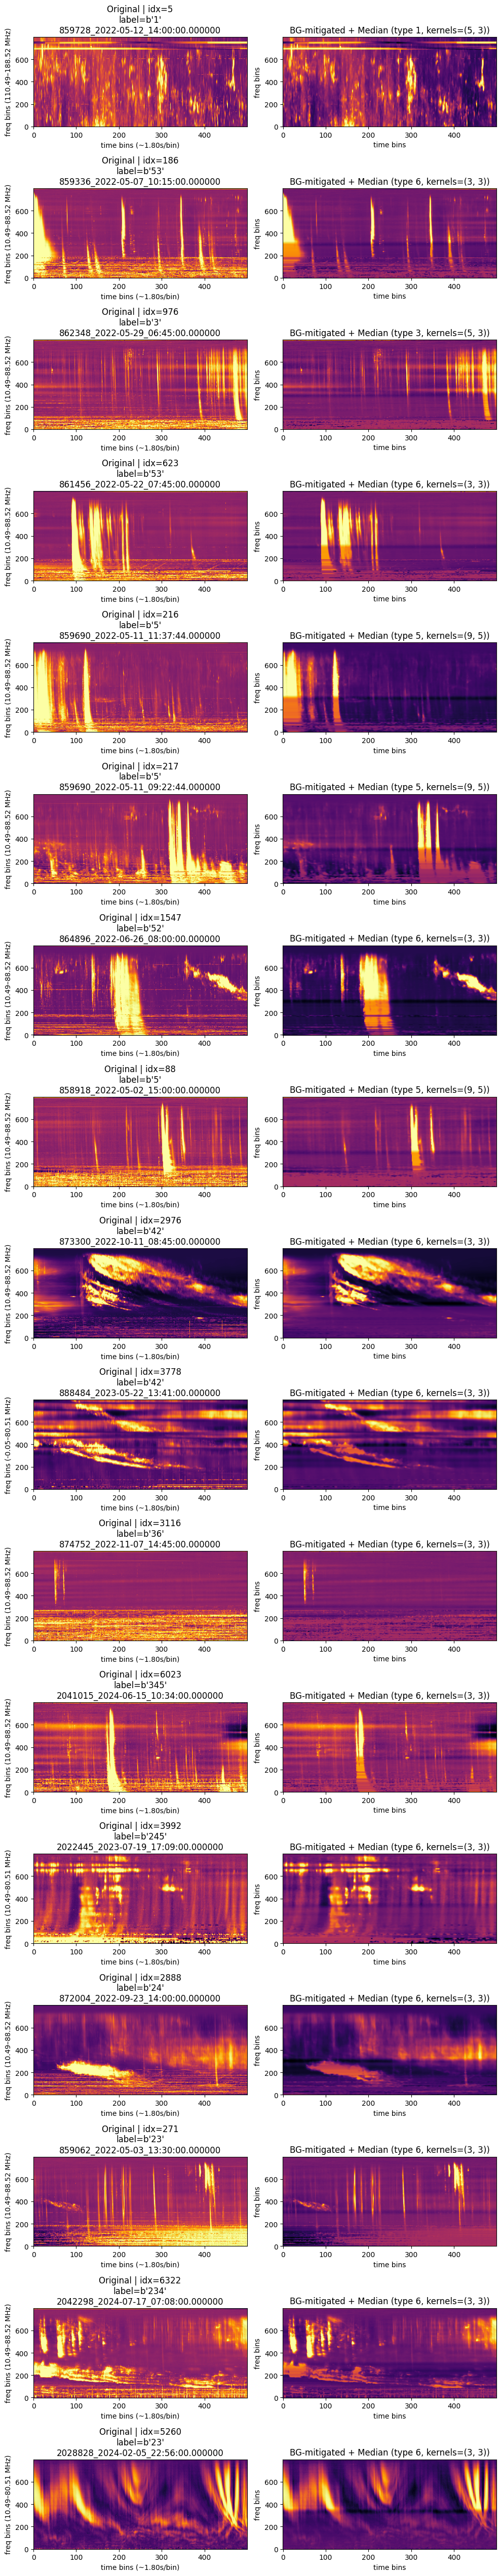

In [19]:
# Background Noise Mitigation (Paper §4.2 only) for 15-min LOFAR-like frames
# - Uses freq_range from H5 (per-sample [fmin,fmax]) to build the frequency axis
# - Applies mitigation to low frequencies with a SOFT CROSS-FADE (Option 2)
# - Plots selected samples: Original vs Mitigated
# - No calibration removal, no median gradient filter

import h5py, numpy as np, matplotlib.pyplot as plt
from typing import Optional, Tuple, Dict, Sequence

# -------------------- User config --------------------
h5_path = '../../project/lofarsw/Data/Dynspec/labelled_dataset.h5'
DATA_KEY, LABELS_KEY, TS_KEY, FREQ_RANGE_KEY = 'data', 'labels', 'timestamps', 'freq_range'

# Mitigation hyperparams
k: float = 1.2                 # threshold multiplier (paper suggests 1–3; start with 2)
T_short_s: float = 30.0        # short-term window in seconds (paper uses ~60 s)
use_robust: bool = True       # if True → median/MAD for long-term stats

# Low-frequency application settings (SOFT cross-fade)
f_cut_MHz: Optional[float] = 40.0      # central cutoff in MHz for low-band mitigation
low_band_fraction: Optional[float] = None  # if f_cut_MHz is None, use lower X% of band
ramp_df_MHz: float = 3.0               # cross-fade half-width around the cutoff (2*df total ramp)

# Visualization
SAMPLE_IDXS: Sequence[int] = [5, 186, 976, 623, 216, 217, 1547, 88, 2976,3778,3116,6023, 3992, 2888,271,6322,5260 ]
CMAP = 'inferno'

# -------------------- Utilities --------------------
def rolling_mean_along_time(image: np.ndarray, win: int) -> np.ndarray:
    """Row-wise rolling mean over time (columns). Ensures output width == input width."""
    H, W = image.shape
    if win < 1:
        return image.copy()
    if win % 2 == 0:
        win += 1
    padL = win // 2
    padR = padL + 1  # extra column on the right fixes off-by-one
    padded = np.pad(image, ((0, 0), (padL, padR)), mode='edge')
    csum = np.cumsum(padded, axis=1, dtype=np.float64)
    out = (csum[:, win:] - csum[:, :-win]) / win
    if out.shape[1] != W:
        raise RuntimeError(f"BUG: rolling mean width {out.shape[1]} != {W}")
    return out

def long_stats_per_row(Ic: np.ndarray, robust: bool=False) -> Tuple[np.ndarray, np.ndarray]:
    """Return (ell_r, sigma_r) per frequency row over the frame."""
    if robust:
        med = np.median(Ic, axis=1)
        mad = np.median(np.abs(Ic - med[:, None]), axis=1)
        return med, 1.4826 * mad
    else:
        return Ic.mean(axis=1), Ic.std(axis=1, ddof=0)

def build_freq_axis_from_range(freq_rng: np.ndarray, H: int) -> np.ndarray:
    """Make a length-H frequency vector (low→high) from [fmin,fmax] MHz."""
    fmin, fmax = float(freq_rng[0]), float(freq_rng[1])
    return np.linspace(fmin, fmax, H)

def soft_lowfreq_weight(freqs: np.ndarray, f_cut: float, df: float) -> np.ndarray:
    """
    1.0 well below f_cut, 0.0 well above, cosine ramp of width 2*df centered at f_cut.
    """
    w = np.ones_like(freqs, dtype=np.float32)
    lo, hi = f_cut - df, f_cut + df
    w[freqs >= hi] = 0.0
    sel = (freqs > lo) & (freqs < hi)
    # map (lo..hi) -> (0..π)
    ramp = (freqs[sel] - lo) / (2*df) * np.pi
    w[sel] = 0.5 * (1 + np.cos(ramp))  # 1→0 cosine
    return w

# --- replace your current mitigate_background_42 with this safer version ---

def mitigate_background_42(
    Ic: np.ndarray,
    freq_range_for_sample: np.ndarray,
    k: float = 1.2,                 # tighter than 2.0
    T_short_s: float = 45.0,        # a bit shorter than 60s to reduce lb “bulb swallowing”
    use_robust: bool = True,        # use median/MAD for lr, rr
    f_cut_MHz: Optional[float] = 40.0,
    low_band_fraction: Optional[float] = None,
    ramp_df_MHz: float = 3.0,
    bias_match_highband: bool = True,
    return_scaled: bool = False,
    # --- NEW guards ---
    z_protect: float = 2.0,         # pixels above lr + z*rr are treated as bursts (don’t subtract lb)
    sub_fraction_cap: float = 0.6   # never subtract more than 60% of Ic at any pixel
) -> Tuple[np.ndarray, Dict]:

    H, W = Ic.shape
    sec_per_col = 900.0 / float(W)
    win_cols = int(round(T_short_s / sec_per_col))
    if win_cols < 1: win_cols = 1
    if win_cols % 2 == 0: win_cols += 1

    # short-term local mean
    lb = rolling_mean_along_time(Ic, win=win_cols)
    assert lb.shape == Ic.shape

    # long-term baseline per row (ROBUST by default)
    lr, rr = long_stats_per_row(Ic, robust=use_robust)
    lr_full = np.broadcast_to(lr[:, None], Ic.shape)
    rr_full = np.broadcast_to(rr[:, None], Ic.shape)

    # frequency axis
    f_axis = build_freq_axis_from_range(freq_range_for_sample, H)

    # soft low-band weights
    if f_cut_MHz is not None:
        w_rows = soft_lowfreq_weight(f_axis, f_cut=float(f_cut_MHz), df=float(ramp_df_MHz))
    elif low_band_fraction is not None:
        frac = float(np.clip(low_band_fraction, 0.0, 1.0))
        cutoff = np.quantile(f_axis, frac)
        w_rows = soft_lowfreq_weight(f_axis, f_cut=float(cutoff), df=float(ramp_df_MHz))
    else:
        w_rows = np.ones(H, dtype=np.float32)
    w2 = w_rows[:, None]

    # base decision (paper)
    threshold = lr[:, None] + k * rr[:, None]
    use_lb_base = (lb <= threshold)  # True → subtract lb, else subtract lr

    # --- Burst protection: if Ic is well above lr, treat as burst → do NOT use lb branch
    # This overrides use_lb in bright pixels.
    burst_mask = (Ic >= (lr_full + z_protect * rr_full))
    use_lb = np.where(burst_mask, False, use_lb_base)

    # desired subtraction amount per pixel
    sub_amount = np.where(use_lb, lb, lr_full)

    # --- Cap subtraction so we never remove too much of the signal
    if sub_fraction_cap is not None and sub_fraction_cap > 0:
        cap = sub_fraction_cap * np.maximum(Ic, 1e-6)  # avoid zero cap
        sub_amount = np.minimum(sub_amount, cap)

    # weighted subtraction
    Ir = Ic - w2 * sub_amount

    # bias-match to remove DC seam
    if bias_match_highband:
        thr = np.quantile(w_rows, 0.9)  # top ~10% lowest weights = reference
        high_mask = (w_rows <= thr)
        if np.any(high_mask):
            mu_ref = float(np.median(Ir[high_mask, :].mean(axis=1)))
            mu_row = Ir.mean(axis=1)
            delta = (mu_ref - mu_row).astype(np.float32)
            Ir += (w_rows[:, None] * delta[:, None])

    # clip for stability/plotting
    Ir = np.clip(Ir, 0.0, None)

    stats = dict(
        H=H, W=W,
        sec_per_col=sec_per_col,
        win_cols=win_cols,
        k=k, use_robust=use_robust,
        f_axis_MHz=f_axis,
        f_cut_MHz=f_cut_MHz,
        low_band_fraction=low_band_fraction,
        ramp_df_MHz=ramp_df_MHz,
        bias_match_highband=bias_match_highband,
        z_protect=z_protect,
        sub_fraction_cap=sub_fraction_cap,
        lr=lr, rr=rr,
        w_rows=w_rows
    )

    if return_scaled:
        lo, hi = np.percentile(Ir, [1.0, 99.0])
        if hi <= lo: hi = lo + 1e-6
        stats['Ir_scaled'] = np.clip((Ir - lo) / (hi - lo), 0.0, 1.0).astype(np.float32)

    return Ir, stats

   

# -------------------- Load H5 --------------------
def load_h5(h5_path: str):
    with h5py.File(h5_path, 'r') as f:
        data = f[DATA_KEY][:]
        labels = f[LABELS_KEY][:len(data)] if LABELS_KEY in f else None
        ts = None
        if TS_KEY in f:
            raw = f[TS_KEY][:len(data)]
            try:
                ts = [s.decode() if hasattr(s, 'decode') else str(s) for s in raw]
            except Exception:
                ts = [str(s) for s in raw]
        freq_range = f[FREQ_RANGE_KEY][:len(data)]  # shape (N,2): [[fmin,fmax], ...]
    return data, labels, ts, freq_range

try:
    data, labels, timestamps, freq_ranges = load_h5(h5_path)
    print("Loaded:", data.shape, "| freq_range shape:", freq_ranges.shape)
except Exception as e:
    print("Failed to load H5 file:", e)
    data = (np.random.rand(10, 800, 500).astype(np.float32)*0.08)
    labels = np.zeros((10,), dtype=np.int32)
    timestamps = [None]*len(data)
    freq_ranges = np.c_[np.full(len(data), 10.5), np.full(len(data), 88.5)]
    print("Using dummy data:", data.shape)

# -------------------- Print the exact equation used (for your log) --------------------
sec_per_col = 900.0 / float(data.shape[2])  # ~1.8 s
win_cols = int(round(T_short_s / sec_per_col))
if win_cols % 2 == 0: win_cols += 1
print("\nEquation used (Section 4.2, background only) with SOFT cross-fade:")
print(f"Short-term window: T_short={T_short_s:.1f}s → w={win_cols} cols (Δt={sec_per_col:.3f}s/col)")
print("If lb(f,t) ≤ lr(f) + k*rr(f):  subtract lb(f,t); else subtract lr(f).")
if f_cut_MHz is not None:
    print(f"Apply with soft weight centered at f_cut={f_cut_MHz:.1f} MHz (±{ramp_df_MHz:.1f} MHz ramp).")
elif low_band_fraction is not None:
    print(f"Apply with soft weight centered at lower {100*low_band_fraction:.1f}% cutoff (±{ramp_df_MHz:.1f} MHz ramp).")
else:
    print("Apply across full band with weight=1 (no ramp).")

# === NEXT CELL: Paper-style median filtering (per SRB type) on top of background mitigation ===
from scipy.ndimage import median_filter
import numpy as np
import matplotlib.pyplot as plt

# Per-type median kernels (freq_bins, time_bins). Tweak per your data if needed.
MEDIAN_KERNELS_DEFAULT = {
    1: (5, 3),    # Type I: narrowband/short → small, preserves thin lines
    2: (11, 5),   # Type II: drifting bands → wider in freq, modest in time
    3: (5, 3),    # Type III: fast/thin → small to avoid smearing
    4: (15, 9),   # Type IV: broadband continuum → larger smoothing
    5: (9, 5),    # Type V: broadband impulsive → medium
    6: (3, 3),    # Nothing: very light (or set to (1,1) to skip)
}

APPLY_MEDIAN = True                 # turn median stage on/off
KERNELS = MEDIAN_KERNELS_DEFAULT    # kernel table to use
POST_SCALE_FOR_PLOTS = False        # set True to use same vmin/vmax for both panels
BIAS_MATCH_HIGHBAND = True          # keep consistent with your background stage usage

def to_int_label(lbl) -> int:
    """Map labels that may be bytes or strings to int (1..6). Defaults to 6 if unknown."""
    if isinstance(lbl, (bytes, bytearray)):
        s = lbl.decode(errors='ignore')
    else:
        s = str(lbl)
    s_stripped = s.strip().strip("b").strip("'").strip('"')
    try:
        v = int(float(s_stripped))
        if 1 <= v <= 6:
            return v
    except Exception:
        pass
    for k in ('1','2','3','4','5','6'):
        if f"'{k}'" in s or f'"{k}"' in s:
            return int(k)
    return 6

def median_filter_per_type(
    Ir: np.ndarray,
    srb_type: int,
    kernels: dict = KERNELS,
    clip_nonneg: bool = True
) -> np.ndarray:
    """
    Apply a type-specific 2-D median filter (freq×time) to a mitigated frame Ir.
    Ensures odd kernel sizes as in the paper’s appendix implementation.
    """
    kf, kt = kernels.get(int(srb_type), kernels[6])
    kf = int(max(1, kf));  kt = int(max(1, kt))
    if kf % 2 == 0: kf += 1
    if kt % 2 == 0: kt += 1
    out = median_filter(Ir, size=(kf, kt), mode='nearest')
    if clip_nonneg:
        out = np.clip(out, 0.0, None)
    return out

def robust_frame_scale(x: np.ndarray, p_lo=1.0, p_hi=99.0, eps=1e-6) -> np.ndarray:
    """Optional: robust [0,1] scaler for training/export (not used for raw plots by default)."""
    lo, hi = np.percentile(x, [p_lo, p_hi])
    if hi <= lo: hi = lo + eps
    x = np.clip(x, lo, hi)
    return ((x - lo) / (hi - lo + eps)).astype(np.float32)

def parse_multilabel(lbl) -> set[int]:
    s = lbl.decode() if isinstance(lbl, (bytes, bytearray)) else str(lbl)
    return {int(ch) for ch in s if ch in '123456'}

def pick_kernel_for_multilabel(lbl, kernels=MEDIAN_KERNELS_DEFAULT) -> tuple[int,int]:
    types = parse_multilabel(lbl)
    if not types:
        return kernels[6]
    # policy: prefer 3 (thin), then 5, then 2,4,1; fallback to largest needed
    priority = [3, 5, 2, 4, 1, 6]
    for t in priority:
        if t in types:
            return kernels.get(t, kernels[6])
    return kernels[6]


def show_before_after_with_median(idxs, use_scaled_for_plots=False):
    """
    Visualizes: Original vs (Background-mitigated → Median-filtered).
    If use_scaled_for_plots=True, both panels use vmin/vmax from filtered frame percentiles.
    """
    valid = [i for i in idxs if 0 <= i < len(data)]
    if not valid:
        print("No valid indices to plot.")
        return

    n = len(valid)
    fig, axes = plt.subplots(nrows=n, ncols=2, figsize=(10, 3*n))
    if n == 1:
        axes = np.array([axes])

    for r, i in enumerate(valid):
        Ic = np.asarray(data[i], dtype=np.float32)
        fr = freq_ranges[i]
        srb_type = to_int_label(labels[i]) if labels is not None else 6

        if not np.isfinite(Ic).all() or np.max(Ic) == np.min(Ic):
            print(f"Skipping idx {i} due to invalid data.")
            axes[r,0].axis('off'); axes[r,1].axis('off')
            continue

        # Step 1: Background mitigation (uses your function from the previous cell)
        Ir, st = mitigate_background_42(
            Ic, fr,
            k=k, T_short_s=T_short_s, use_robust=use_robust,
            f_cut_MHz=f_cut_MHz, low_band_fraction=low_band_fraction,
            ramp_df_MHz=ramp_df_MHz,
            bias_match_highband=BIAS_MATCH_HIGHBAND,
            return_scaled=False
        )

        # Step 2: Type-specific median filter (paper appendix style)
        kf, kt = pick_kernel_for_multilabel(labels[i])
        If = median_filter(Ir, size=(kf, kt), mode='nearest')


        # Optional: unify plot scaling using filtered frame stats
        if use_scaled_for_plots or POST_SCALE_FOR_PLOTS:
            vmin1, vmax1 = np.percentile(If, [1.0, 99.0])
            vmin0, vmax0 = vmin1, vmax1
        else:
            vmin0 = vmax0 = vmin1 = vmax1 = None

        a0 = axes[r,0]
        a0.imshow(Ic, aspect='auto', origin='lower', cmap=CMAP, vmin=vmin0, vmax=vmax0)
        a0.set_title(f"Original | idx={i}\nlabel={labels[i] if labels is not None else '?'}\n{timestamps[i] or ''}")
        a0.set_xlabel('time bins (~{:.2f}s/bin)'.format(sec_per_col))
        a0.set_ylabel('freq bins ({}–{} MHz)'.format(*np.round(fr, 2)))

        a1 = axes[r,1]
        a1.imshow(If, aspect='auto', origin='lower', cmap=CMAP, vmin=vmin1, vmax=vmax1)
        a1.set_title(f"BG-mitigated + Median (type {srb_type}, kernels={KERNELS.get(srb_type, KERNELS[6])})")
        a1.set_xlabel('time bins')
        a1.set_ylabel('freq bins')

    plt.tight_layout()
    plt.show()

# Run preview on your chosen indices
show_before_after_with_median(SAMPLE_IDXS)

